# Logistic Regression Using Food Items Dataset

In [688]:
!pip install imbalanced-learn==0.6.0
!pip install scikit-learn==0.22.1

  Using cached scikit-learn-0.22.1.tar.gz (6.9 MB)
  Preparing metadata (setup.py) ... done
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for scikit-learn
  Running setup.py clean for scikit-learn
Failed to build scikit-learn
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (scikit-learn)


In [689]:

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix,ConfusionMatrixDisplay, precision_recall_fscore_support, precision_score, recall_score
from scipy import stats
from sklearn.metrics import roc_auc_score, precision_recall_curve, roc_curve, auc
from sklearn.preprocessing import label_binarize


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/food-items-dataset/food_items.csv


In [690]:
#data = pd.read_csv(r"/kaggle/input/food-items/food_items.csv")
data = pd.read_csv(r"/kaggle/input/food-items-dataset/food_items.csv")
data.head()
#1- This is a classification problem to predict which food class belogns to

,Calories,Total Fat,Saturated Fat,Monounsaturated Fat,Polyunsaturated Fat,Trans Fat,Cholesterol,Sodium,Total Carbohydrate,Dietary Fiber,Sugars,Sugar Alcohol,Protein,Vitamin A,Vitamin C,Calcium,Iron,class
0,149.0,0,0.0,0.0,0.0,0.0,0,9.0,9.8,0.0,0.0,0,1.3,0,0,0,0,'In Moderation'
1,123.0,0,0.0,0.0,0.0,0.0,0,5.0,6.6,0.0,0.0,0,0.8,0,0,0,0,'In Moderation'
2,150.0,0,0.0,0.0,0.0,0.0,0,4.0,11.4,0.0,0.0,0,1.3,0,0,0,0,'In Moderation'
3,110.0,0,0.0,0.0,0.0,0.0,0,6.0,7.0,0.0,0.0,0,0.8,0,0,0,0,'In Moderation'
4,143.0,0,0.0,0.0,0.0,0.0,0,7.0,13.1,0.0,0.0,0,1.0,0,0,0,0,'In Moderation'


### Data Exploration

In [691]:
data.shape

(13260, 18)

In [692]:
data.isnull().sum().sum() # no missing values

0

In [693]:
data.duplicated().sum()

2341

In [694]:
food_df = data.copy()
# No.of duplicates
food_duplicates = food_df.duplicated().sum()
print(f"Number of duplicate rows: {food_duplicates}")

Number of duplicate rows: 2341


In [695]:
# Removing duplicates
food_df = food_df.drop_duplicates()
food_df.shape

(10919, 18)

In [696]:
# Resetting index
food_df = food_df.reset_index(drop=True)

In [697]:
feature_cols = list(food_df.iloc[:, :-1].columns)
feature_cols

['Calories',
 'Total Fat',
 'Saturated Fat',
 'Monounsaturated Fat',
 'Polyunsaturated Fat',
 'Trans Fat',
 'Cholesterol',
 'Sodium',
 'Total Carbohydrate',
 'Dietary Fiber',
 'Sugars',
 'Sugar Alcohol',
 'Protein',
 'Vitamin A',
 'Vitamin C',
 'Calcium',
 'Iron']

In [698]:
food_df.describe()

,Calories,Total Fat,Saturated Fat,Monounsaturated Fat,Polyunsaturated Fat,Trans Fat,Cholesterol,Sodium,Total Carbohydrate,Dietary Fiber,Sugars,Sugar Alcohol,Protein,Vitamin A,Vitamin C,Calcium,Iron
count,10919.000000,10919.000000,10919.000000,10919.000000,10919.000000,10919.000000,10919.000000,10919.000000,10919.000000,10919.000000,10919.000000,10919.000000,10919.000000,10919.000000,10919.00000,10919.000000,10919.000000
mean,138.802271,4.798333,1.573924,0.335205,0.269639,0.054428,9.735690,264.263513,19.288600,1.700559,7.051882,0.128766,5.015469,6.498489,7.11393,5.457002,5.575144
std,95.269372,5.421372,2.468812,1.304086,2.428624,0.346278,22.003703,278.292824,14.659023,3.583341,8.502057,1.185217,5.720368,18.369988,24.93890,8.932506,9.244576
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,80.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,60.000000,6.800000,0.000000,1.000000,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000
50%,120.000000,3.000000,0.500000,0.000000,0.000000,0.000000,0.000000,160.000000,18.000000,1.000000,3.000000,0.000000,3.000000,0.000000,0.00000,2.000000,4.000000
75%,180.000000,7.000000,2.000000,0.000000,0.000000,0.000000,10.000000,400.000000,28.000000,3.000000,11.000000,0.000000,7.000000,6.000000,4.00000,8.000000,8.000000
max,2210.000000,43.000000,22.000000,40.000000,235.000000,11.000000,450.000000,2431.000000,270.000000,305.000000,115.000000,31.000000,70.000000,622.000000,1000.00000,110.000000,170.000000


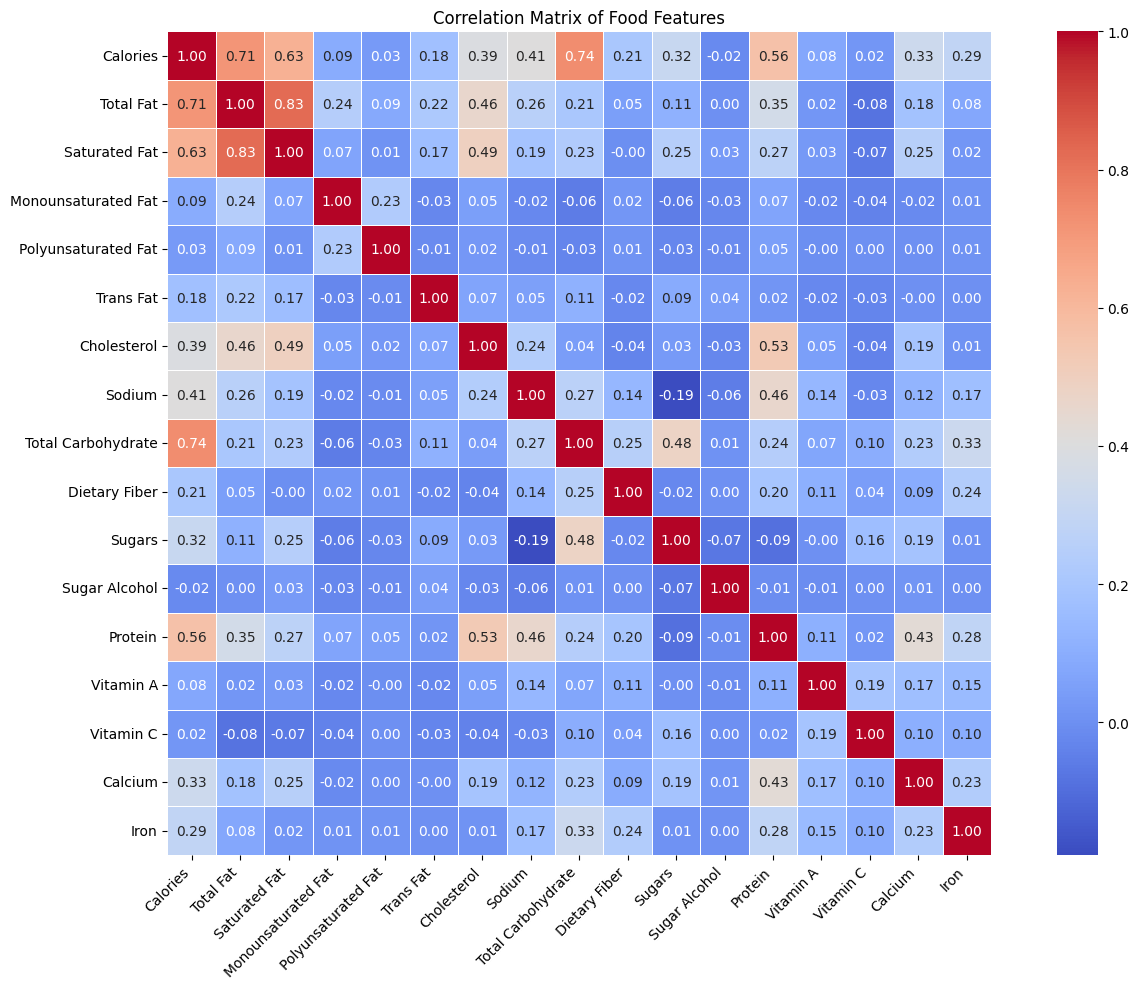

In [699]:
# Correlation Matrix
numeric_df = food_df.drop(columns='class') # no correlations

corr_matrix = numeric_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title("Correlation Matrix of Food Features")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# Data Cleaning

### 1. Removing Duplicates

In [700]:
#already removed

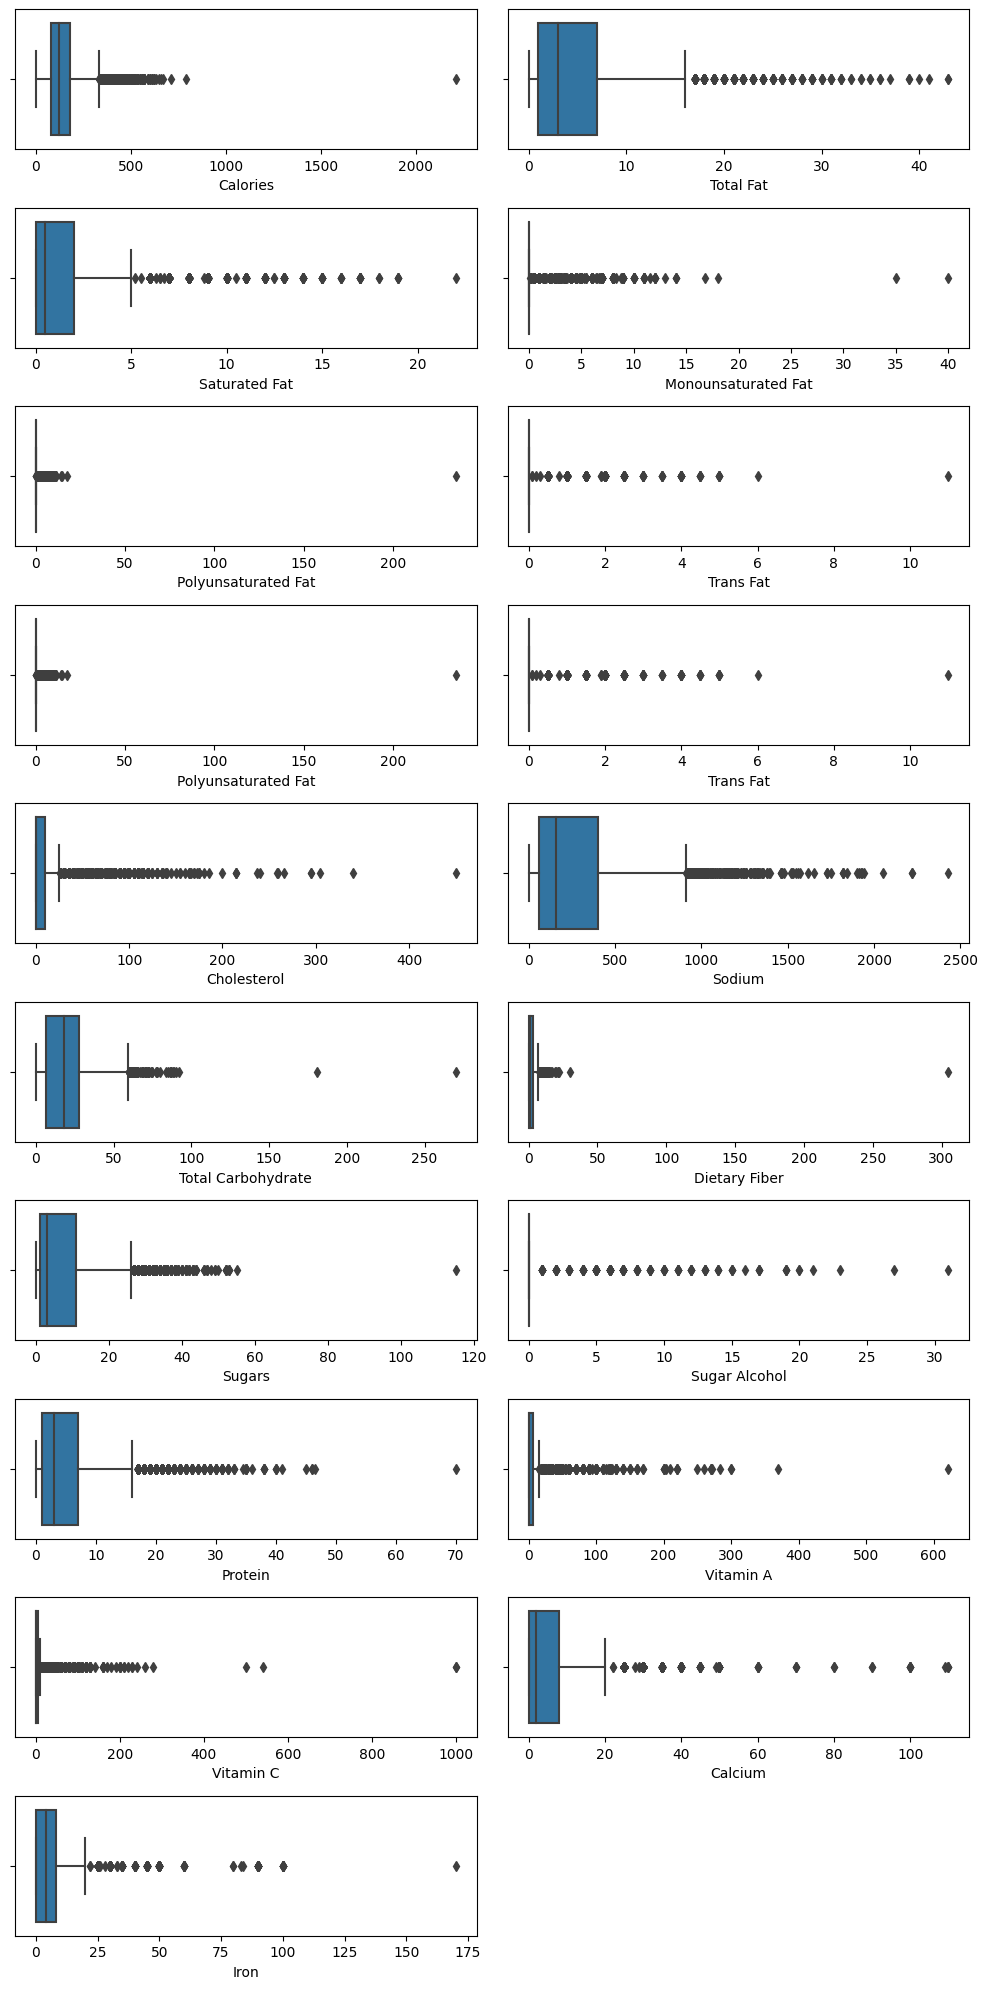

In [701]:
#checking for outliers
#tried a for loop but they werent labeled
plt.figure(figsize=(10, 20))
plt.subplot(10,2,1)
sns.boxplot(x = food_df['Calories'])
plt.subplot(10,2,2)
sns.boxplot(x = food_df['Total Fat'])
plt.subplot(10,2,3)
sns.boxplot(x = food_df['Saturated Fat'])
plt.subplot(10,2,4)
sns.boxplot(x = food_df['Monounsaturated Fat'])
plt.subplot(10,2,5)
sns.boxplot(x = food_df['Polyunsaturated Fat'])
plt.subplot(10,2,6)
sns.boxplot(x = food_df['Trans Fat'])
plt.subplot(10,2,7)
sns.boxplot(x = food_df['Polyunsaturated Fat'])
plt.subplot(10,2,8)
sns.boxplot(x = food_df['Trans Fat'])
plt.subplot(10,2,9)
sns.boxplot(x = food_df['Cholesterol'])
plt.subplot(10,2,10)
sns.boxplot(x = food_df['Sodium'])
plt.subplot(10,2,11)
sns.boxplot(x = food_df['Total Carbohydrate'])
plt.subplot(10,2,12)
sns.boxplot(x = food_df['Dietary Fiber'])
plt.subplot(10,2,13)
sns.boxplot(x = food_df['Sugars'])
plt.subplot(10,2,14)
sns.boxplot(x = food_df['Sugar Alcohol'])
plt.subplot(10,2,15)
sns.boxplot(x = food_df['Protein'])
plt.subplot(10,2,16)
sns.boxplot(x = food_df['Vitamin A'])
plt.subplot(10,2,17)
sns.boxplot(x = food_df['Vitamin C'])
plt.subplot(10,2,18)
sns.boxplot(x = food_df['Calcium'])
plt.subplot(10,2,19)
sns.boxplot(x = food_df['Iron'])
plt.tight_layout()
plt.show()

In [702]:

outlier_columns = food_df.columns.drop(['class','Calories'])
z_scores = stats.zscore(food_df[outlier_columns]) #getting outliers
outliers_z = food_df[(np.abs(z_scores) > 3)]  # Threshold at 3 
food_df = food_df.drop(outliers_z.index) #cleaning them

In [703]:
food_df['class'].value_counts(normalize=True)

class
'In Moderation'    0.516689
'Less Often'       0.415323
'More Often'       0.067988
Name: proportion, dtype: float64

<Axes: xlabel='class'>

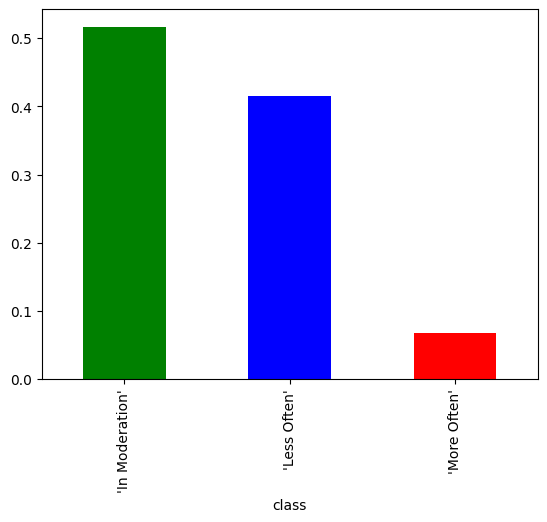

In [704]:
food_df['class'].value_counts(normalize=True).plot.bar(color=['green', 'blue', 'red'])

#### As we can see from the bar chart above, this dataset has three classes: 
- `In Moderation`, `Less Often`, and `More Often`.
-  The three labels are **imbalanced**.
-  For diabetic patients, most food items are in the `In Moderation` and `Less Often` categories. This makes diabetes diet management very hard, so we could build a machine learning model to help patients choose their food.

#### We have three labels meaning our logistic regression model will be multinomial with three classes.

#### `Multinomial logistic regression` model is different from the `one-vs-rest` binary logistic regression. 
- For `one-vs-rest` schema, you need to train an **independent classifier for each class.**
- For example, you need a `More Often` classifier to differentiate a food item between `More Often` and **Not More Often** (or, `In Moderation` and `Less Often`).

# Data Preprocessing

/tmp/ipykernel_36/1354580319.py:3: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.set_option("mode.use_inf_as_na", True)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_n

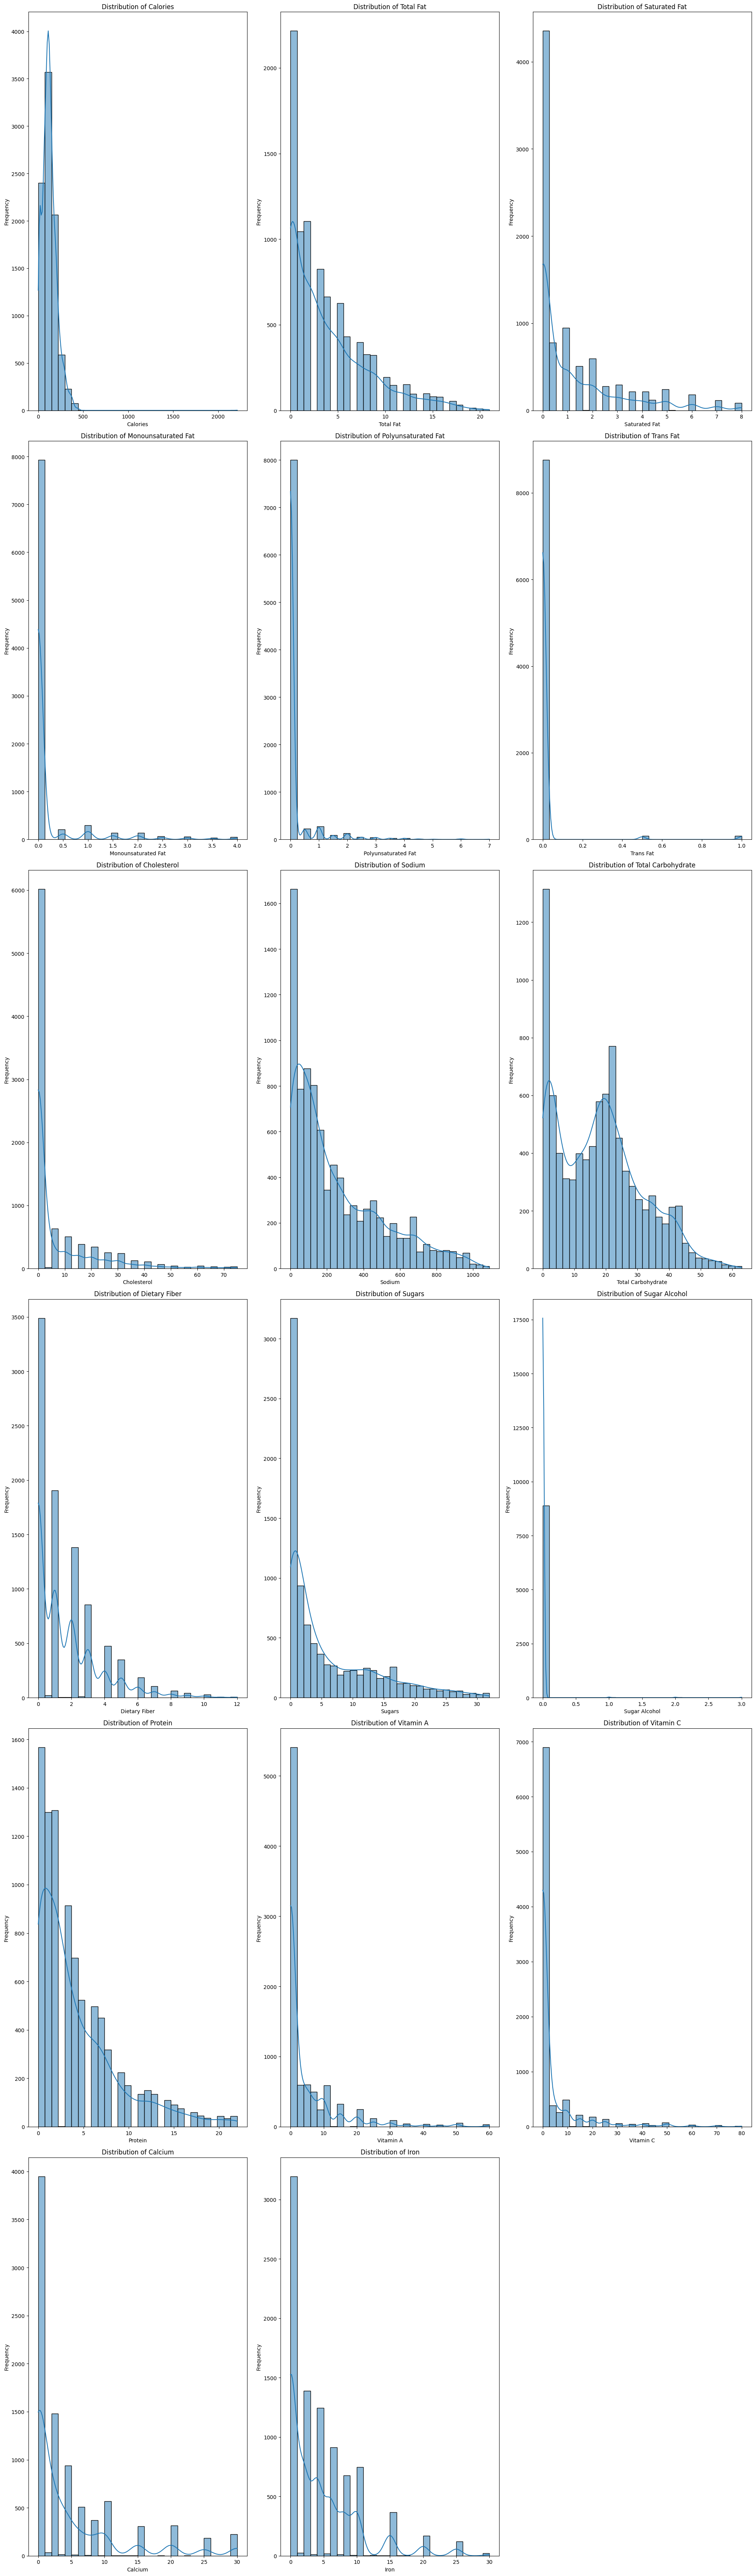

In [705]:
X = food_df.drop(columns='class')

pd.set_option("mode.use_inf_as_na", True)
# distribution of each numerical feature
plt.figure(figsize=(20, len(X.columns) * 4))
for i, col in enumerate(X.columns):
    plt.subplot(len(X.columns) // 3 + 1, 3, i + 1)
    sns.histplot(X[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Applying Log Transformation

In [706]:
X_log = X.copy()
X_log = X_log.apply(lambda col: np.log1p(col))

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

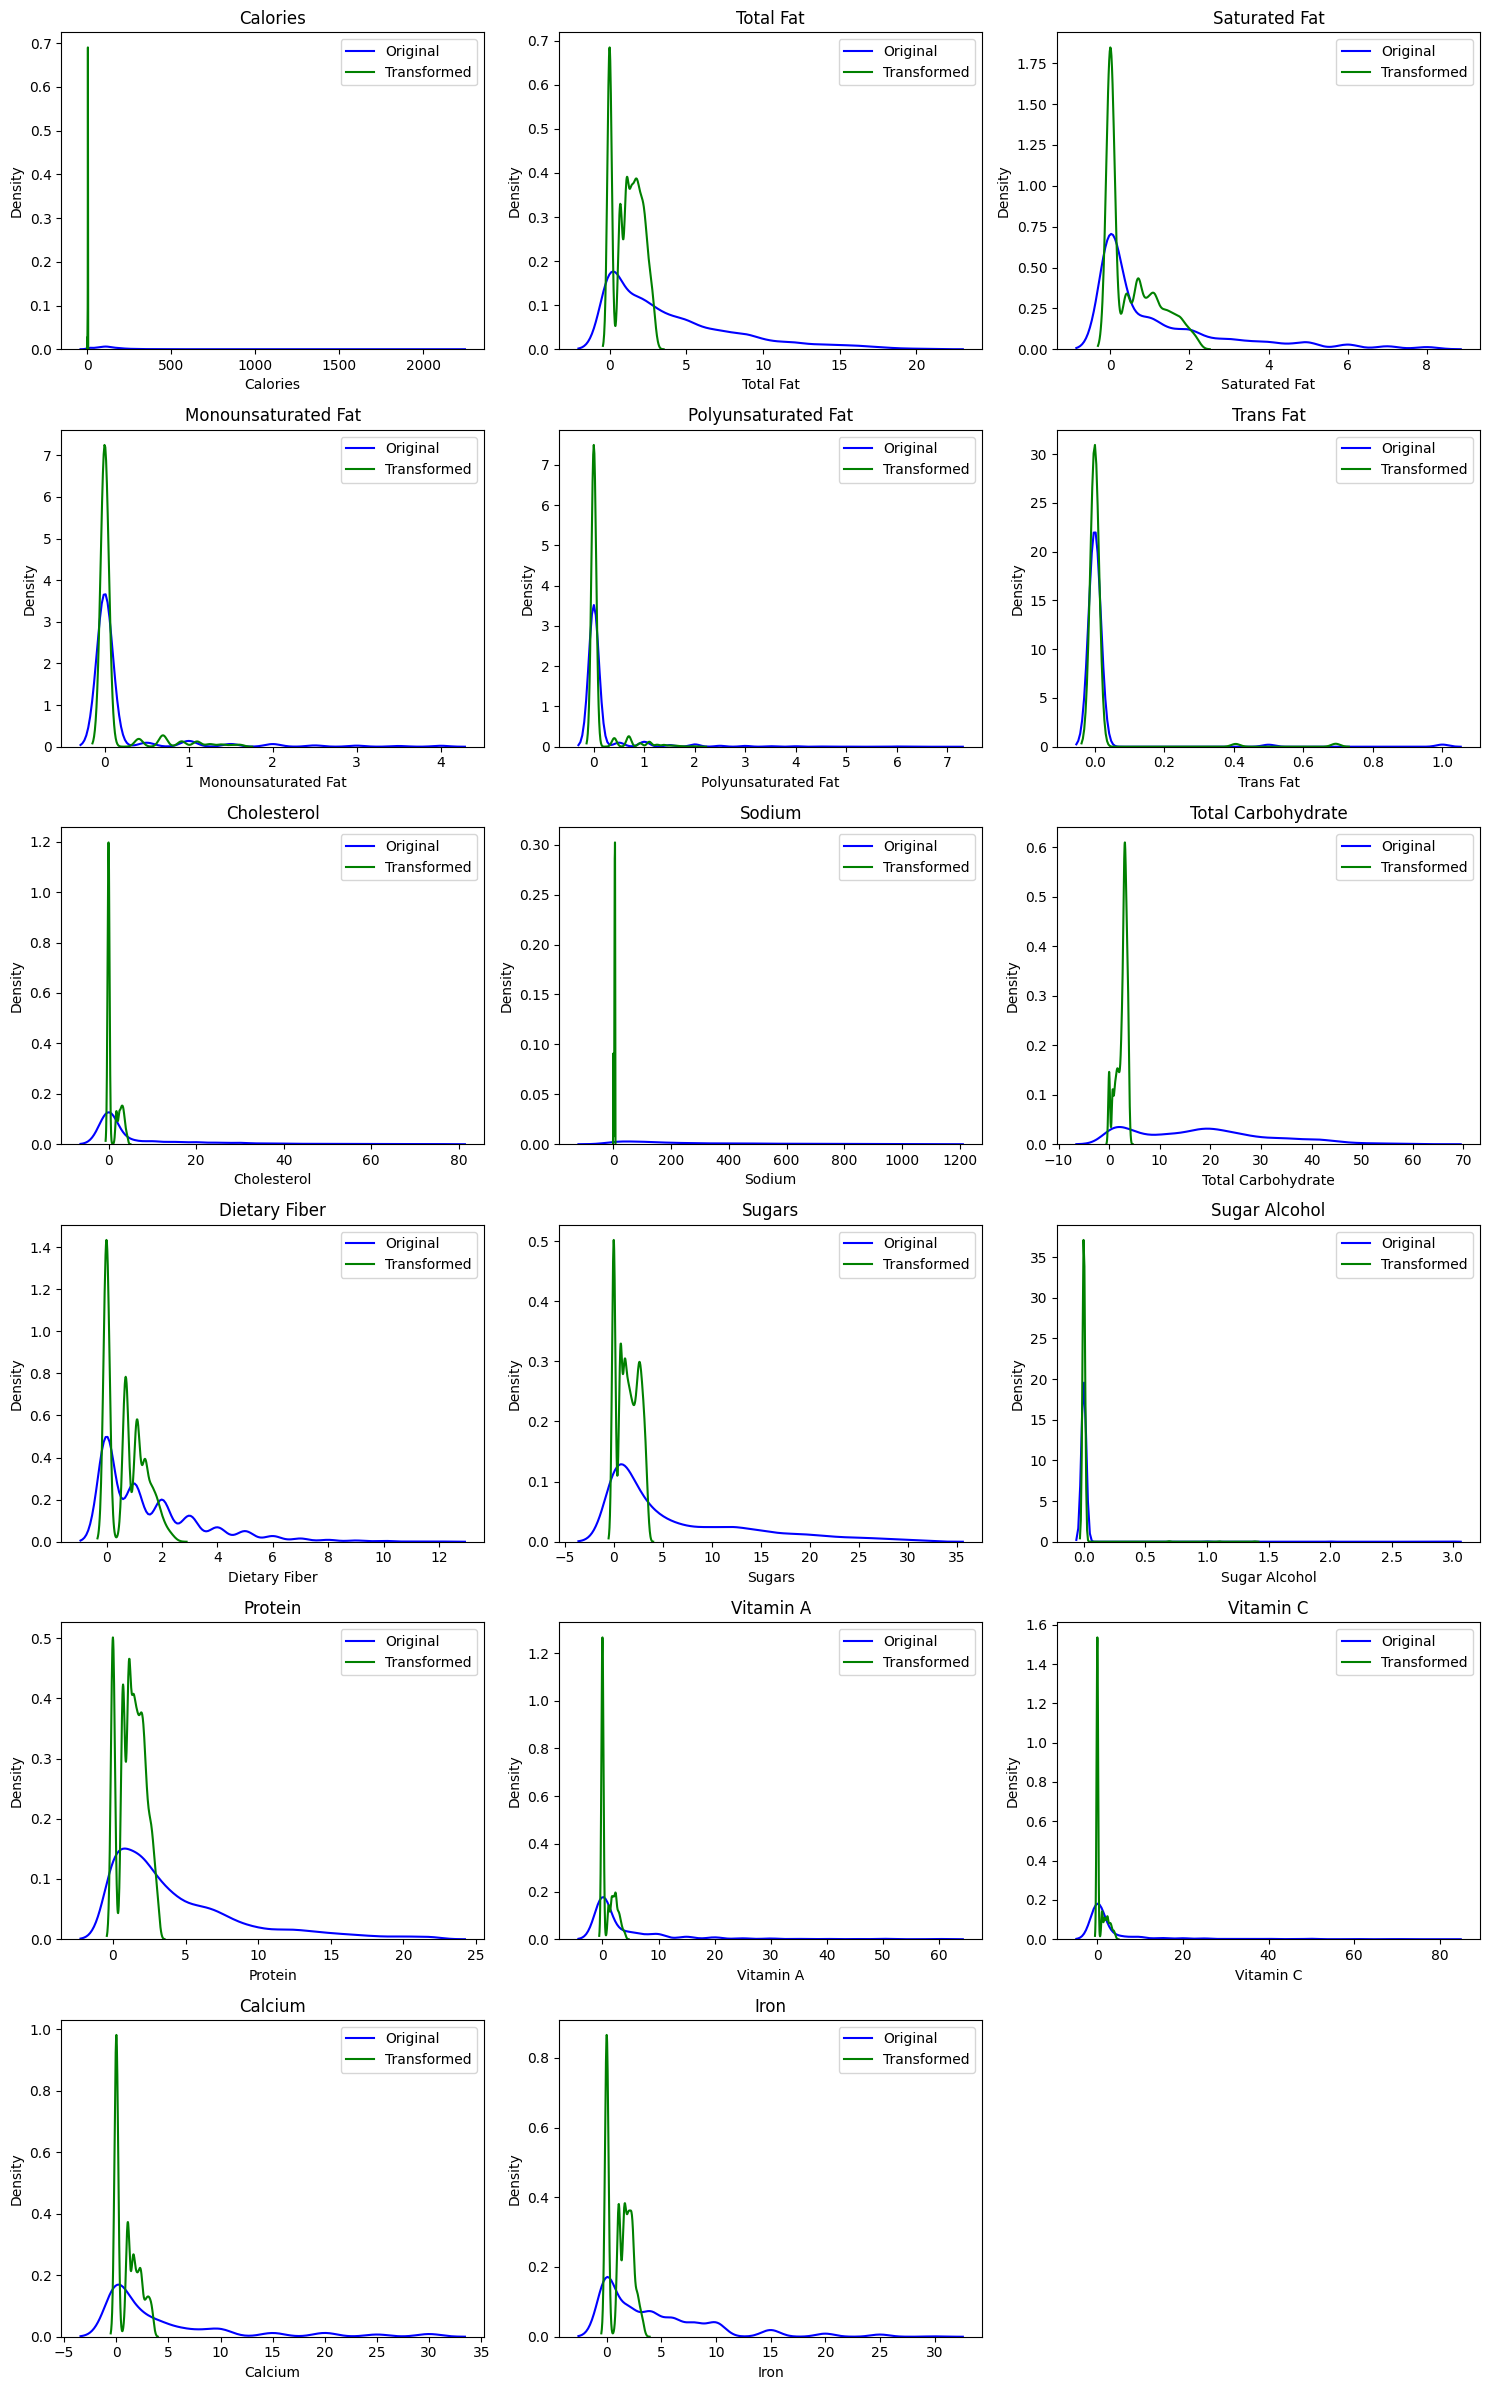

In [707]:
# Comparing before and after log transformation
#Skewness resolved here
def compare_distribution(original, transformed, features, n_cols=3):
    n_rows = (len(features) + n_cols - 1) // n_cols
    plt.figure(figsize=(n_cols * 5, n_rows * 4))

    for i, col in enumerate(features):
        plt.subplot(n_rows, n_cols, i + 1)
        sns.kdeplot(original[col], label='Original', color='blue')
        sns.kdeplot(transformed[col], label='Transformed', color='green')
        plt.title(f"{col}")
        plt.legend()

    plt.tight_layout()
    plt.show()

compare_distribution(X, X_log, X.columns)

### Target Encoding

In [708]:
X = food_df.drop(columns='class')
y = food_df['class']

In [709]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

In [710]:
# observe mapping
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Class Mapping:", label_mapping)

Class Mapping: {"'In Moderation'": 0, "'Less Often'": 1, "'More Often'": 2}


### Data Splitting

In [711]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size = 0.2, random_state=41, stratify=y_encoded)

In [712]:
#Fixing imbalanced data using SMOTE
sm = SMOTE(random_state = 2)
X_train, y_train = sm.fit_resample(X_train, y_train.ravel())
X_train.shape #data increased

(11070, 17)

<Axes: >

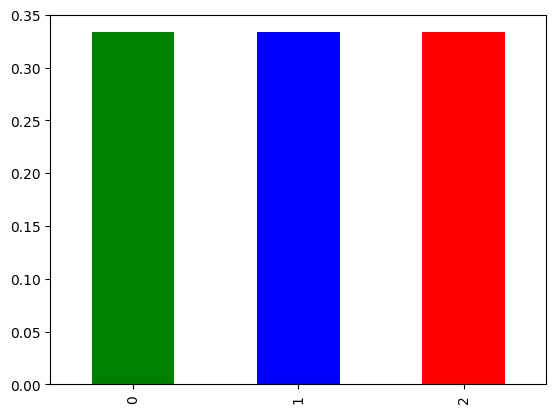

In [713]:
pd.Series(y_train).value_counts(normalize=True).plot.bar(color=['green', 'blue', 'red'])
#class imbalance fixed

### Preprocessing Pipeline

In [714]:
log_transformer = FunctionTransformer(np.log1p, validate=True)

pipeline = Pipeline([
    ('log', log_transformer),
    ('scaler', StandardScaler())
])

X_train_scaled = pipeline.fit_transform(X_train)

# transforming X_test
X_test_scaled = pipeline.transform(X_test)


In [715]:
print(f"Training dataset shape, X_train: {X_train_scaled.shape}, y_train: {y_train.shape}")

Training dataset shape, X_train: (11070, 17), y_train: (11070,)


In [716]:
print(f"Testing dataset shape, X_test: {X_test_scaled.shape}, y_test: {y_test.shape}")

Testing dataset shape, X_test: (1786, 17), y_test: (1786,)


# Multinomial Logistic Regression

In [717]:
model_no_reg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
model_no_reg.fit(X_train_scaled, y_train)
yp_no_reg = model_no_reg.predict(X_test_scaled)

model_lasso = LogisticRegression(multi_class='multinomial', solver='saga', max_iter=1000, random_state=42, penalty='l1', C=0.01)
model_lasso.fit(X_train_scaled, y_train)
yp_lasso = model_lasso.predict(X_test_scaled)

model_ridge = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42, penalty='l2', C=0.01)
model_ridge.fit(X_train_scaled, y_train)
yp_ridge = model_ridge.predict(X_test_scaled)

model_elastic = LogisticRegression(multi_class='multinomial', solver='saga', max_iter=1000, random_state=42, penalty='elasticnet', C=0.01, l1_ratio=0.5)
model_elastic.fit(X_train_scaled, y_train)
yp_elastic = model_elastic.predict(X_test_scaled)



In [718]:
def evaluate_metrics():
    results = []
    models = {
        "No Regularization": model_no_reg,
        "Ridge (L2)": model_ridge,
        "Lasso (L1)": model_lasso,
        "Elastic Net (L1+L2)": model_elastic,
    }
    
    for name, model in models.items():
        ypred = model.predict(X_test_scaled)
        precision, recall, f1, _ = precision_recall_fscore_support(y_test, ypred, average='macro')
        precisionw, recallw, f1w, _ = precision_recall_fscore_support(y_test, ypred, average='weighted')
        yprob = model.predict_proba(X_test_scaled)
        auc = roc_auc_score(y_test, yprob, multi_class='ovr', average='macro')
        results.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test,ypred),
            "Precision-Macro": precision,
            "Recall-Macro": recall,
            "F1score-Macro": f1,
            "Precision-Weighted": precisionw,
            "Recall-Weighted": recallw,
            "F1score-Weighted": f1w,
            "AUC":auc,
        })
    
    df_results = pd.DataFrame(results)
    return df_results

In [719]:
evaluate_metrics()# we conclude no reg is the best in multinomial

,Model,Accuracy,Precision-Macro,Recall-Macro,F1score-Macro,Precision-Weighted,Recall-Weighted,F1score-Weighted,AUC
0,No Regularization,0.780515,0.745901,0.841312,0.780631,0.788991,0.780515,0.780336,0.918107
1,Ridge (L2),0.776036,0.734962,0.841081,0.771240,0.787621,0.776036,0.776071,0.916220
2,Lasso (L1),0.776036,0.732811,0.840993,0.769361,0.788171,0.776036,0.776270,0.915374
3,Elastic Net (L1+L2),0.774356,0.732372,0.839997,0.768769,0.786481,0.774356,0.774425,0.915835


In [720]:
model_no_regOVR = LogisticRegression(multi_class='ovr', solver='lbfgs', max_iter=1000, random_state=42)
model_no_regOVR.fit(X_train_scaled, y_train)
yp_no_regOVR = model_no_regOVR.predict_proba(X_test_scaled)

model_lassoOVR = LogisticRegression(multi_class='ovr', solver='saga', max_iter=1000, random_state=42, penalty='l1', C=0.01)
model_lassoOVR.fit(X_train_scaled, y_train)

model_ridgeOVR = LogisticRegression(multi_class='ovr', solver='lbfgs', max_iter=1000, random_state=42, penalty='l2', C=0.01)
model_ridgeOVR.fit(X_train_scaled, y_train)

model_elasticOVR = LogisticRegression(multi_class='ovr', solver='saga', max_iter=1000, random_state=42, penalty='elasticnet', C=0.01, l1_ratio=0.5)
model_elasticOVR.fit(X_train_scaled, y_train)



LogisticRegression(C=0.01, l1_ratio=0.5, max_iter=1000, multi_class='ovr',
                   penalty='elasticnet', random_state=42, solver='saga')

In [721]:
def evaluate_metricsOVR():
    results = []
    models = {
        "No Regularization": model_no_regOVR,
        "Ridge (L2)": model_ridgeOVR,
        "Lasso (L1)": model_lassoOVR,
        "Elastic Net (L1+L2)": model_elasticOVR,
    }
    
    for name, model in models.items():
        ypred = model.predict(X_test_scaled)
        precision, recall, f1, _ = precision_recall_fscore_support(y_test, ypred, average='macro')
        precisionw, recallw, f1w, _ = precision_recall_fscore_support(y_test, ypred, average='weighted')
        yprob = model.predict_proba(X_test_scaled)
        auc = roc_auc_score(y_test, yprob, multi_class='ovr', average='macro')
        results.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test,ypred),
            "Precision-Macro": precision,
            "Recall-Macro": recall,
            "F1score-Macro": f1,
            "Precision-Weighted": precisionw,
            "Recall-Weighted": recallw,
            "F1score-Weighted": f1w,
            "AUC":auc,
        })
    
    df_results = pd.DataFrame(results)
    return df_results

In [722]:
evaluate_metricsOVR() #almost similar results

,Model,Accuracy,Precision-Macro,Recall-Macro,F1score-Macro,Precision-Weighted,Recall-Weighted,F1score-Weighted,AUC
0,No Regularization,0.780515,0.740640,0.844410,0.776408,0.792095,0.780515,0.780489,0.920730
1,Ridge (L2),0.767637,0.719768,0.836016,0.756173,0.784061,0.767637,0.768064,0.916507
2,Lasso (L1),0.770997,0.724880,0.837919,0.761490,0.785499,0.770997,0.771376,0.917674
3,Elastic Net (L1+L2),0.764838,0.716998,0.833858,0.753540,0.781189,0.764838,0.765326,0.917143


In [ ]:
# {'accuracy': 0.7893772893772893,
#  'recall': array([0.80714958, 0.78304743, 0.69230769]),
#  'precision': array([0.77366997, 0.80665281, 0.79646018]),
#  'f1score': array([0.79005525, 0.79467486, 0.74074074])}
#Rezults before balancing, inconsistent results

In [723]:
no_reg_cf = confusion_matrix(y_test, yp_no_reg)
lasso_cf = confusion_matrix(y_test, yp_lasso)
ridge_cf = confusion_matrix(y_test, yp_ridge)
elastic_cf = confusion_matrix(y_test, yp_elastic)

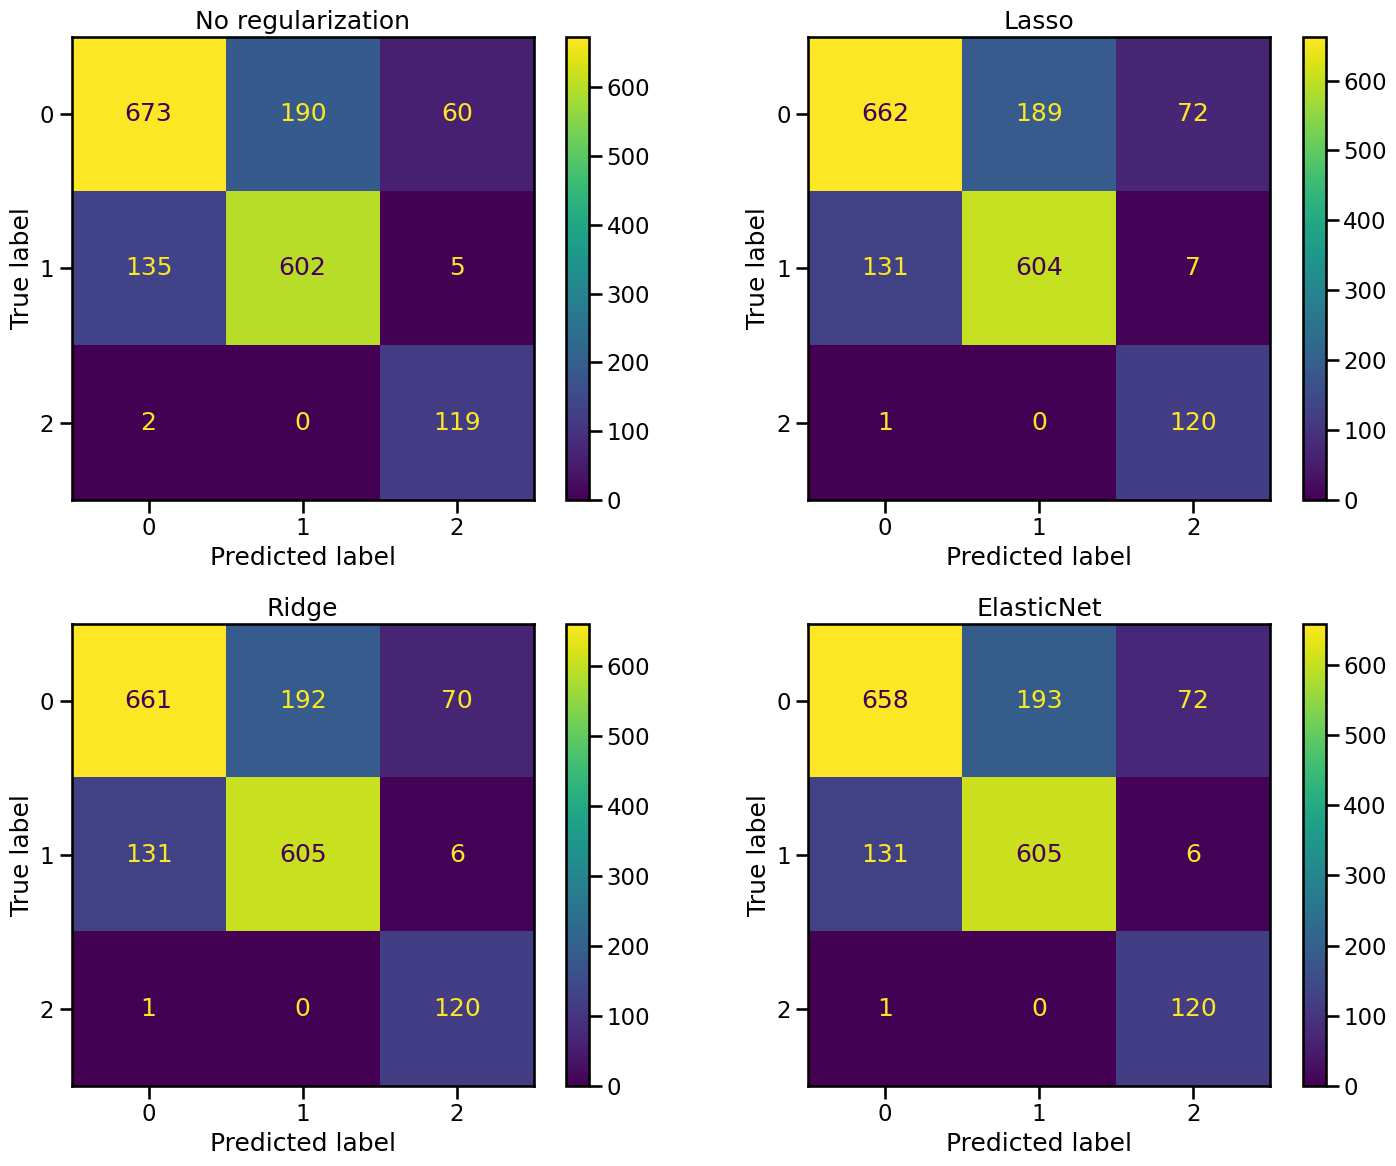

In [724]:
sns.set_context('talk')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=no_reg_cf, display_labels=clf.classes_)
disp.plot(ax=axes[0, 0]) 
axes[0, 0].set_title("No regularization")

disp = ConfusionMatrixDisplay(confusion_matrix=lasso_cf, display_labels=clf.classes_)
disp.plot(ax=axes[0, 1])
axes[0, 1].set_title("Lasso")

disp = ConfusionMatrixDisplay(confusion_matrix=ridge_cf, display_labels=clf.classes_)
disp.plot(ax=axes[1, 0])
axes[1, 0].set_title("Ridge")

disp = ConfusionMatrixDisplay(confusion_matrix=elastic_cf, display_labels=clf.classes_)
disp.plot(ax=axes[1, 1])
axes[1, 1].set_title("ElasticNet")

plt.tight_layout() 
plt.show() #good

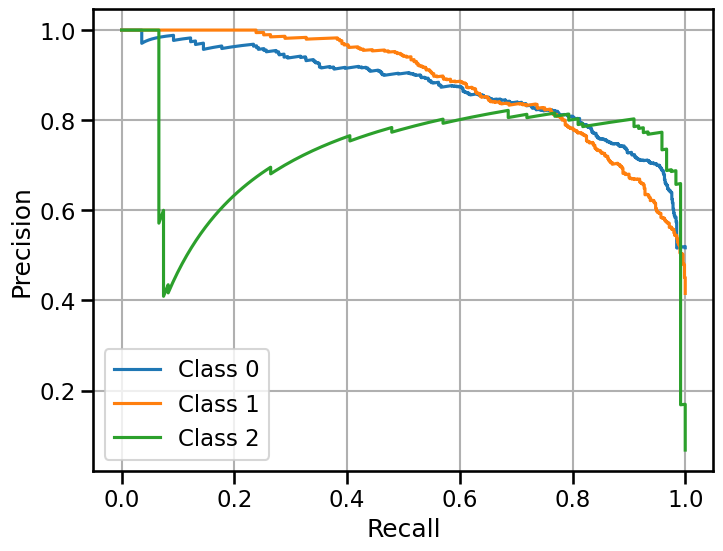

In [725]:
#binarize y_test
y_test_binarized = label_binarize(y_test, classes=model_no_reg.classes_)
# plotting precision recall curve per class
plt.figure(figsize=(8, 6))
for i in range(len(model_no_reg.classes_)):
    precision, recall, _ = precision_recall_curve(y_test_binarized[:, i], y_proba[:, i])
    plt.plot(recall, precision, label=f'Class {model_no_reg.classes_[i]}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid()
plt.show()

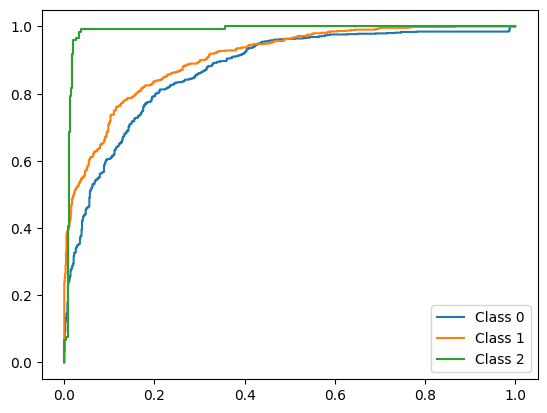

In [743]:
#Same thing for the ROC curve
y_test_bin = label_binarize(y_test, classes=model_no_reg.classes_)

plt.figure()
for i in range(len(model_no_reg.classes_)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i}')

plt.legend()
plt.show()


### Features Importance

In [727]:
clf.coef_ #already done

array([[ 6.76602044e-01,  7.67592741e-01, -5.77531202e-01,
        -2.09521672e-03,  4.71180116e-01, -2.50865916e-01,
         3.56259684e-01,  6.30409496e-02,  8.53364751e-01,
         2.05965499e-01, -4.78542680e-01, -5.51314959e-03,
         1.76138351e-01, -2.03435757e-02, -8.27453260e-02,
         1.06836524e-01, -6.87433173e-02],
       [ 1.58627211e+00,  1.02294955e+00,  8.64894030e-01,
         1.28592925e-02,  4.87414826e-01, -2.46584921e-01,
         3.87127959e-01, -1.35111339e-01,  7.18978348e-01,
        -4.61946362e-01,  1.27293074e-01, -6.19097999e-03,
        -4.84377115e-01, -9.77900961e-02, -1.22953714e-02,
         9.31967093e-02,  2.07626656e-02],
       [-2.26287415e+00, -1.79054229e+00, -2.87362828e-01,
        -1.07640757e-02, -9.58594943e-01,  4.97450837e-01,
        -7.43387643e-01,  7.20703896e-02, -1.57234310e+00,
         2.55980862e-01,  3.51249606e-01,  1.17041296e-02,
         3.08238764e-01,  1.18133672e-01,  9.50406973e-02,
        -2.00033233e-01,  4.7

#### The `coef_` is a coefficients list with three elements, one element is the actual coefficent for class 0, 1, 2.
- To better analyze the coefficients, use three utility methods to sort and visualize them.

In [728]:
# Extract and sort feature coefficients
def get_feature_coefs(regression_model, label_index, columns):
    coef_dict = {}
    for coef, feat in zip(regression_model.coef_[label_index, :], columns):
        if abs(coef) >= 0.01:
            coef_dict[feat] = coef
    # Sort coefficients
    coef_dict = {k: v for k, v in sorted(coef_dict.items(), key=lambda item: item[1])}
    return coef_dict

# bar colors based on if value is negative or positive
def get_bar_colors(values):
    color_vals = []
    for val in values:
        if val <= 0:
            color_vals.append('r')
        else:
            color_vals.append('g')
    return color_vals

# visualizing coefficients
def visualize_coefs(coef_dict):
    features = list(coef_dict.keys())
    values = list(coef_dict.values())
    y_pos = np.arange(len(features))
    color_vals = get_bar_colors(values)
    plt.rcdefaults()
    fig, ax = plt.subplots()
    ax.barh(y_pos, values, align='center', color=color_vals)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(features)
    # labels read top-to-bottom
    ax.invert_yaxis()  
    ax.set_xlabel('Feature Coefficients')
    ax.set_title('')
    plt.show()

#### Coefficients for Classes

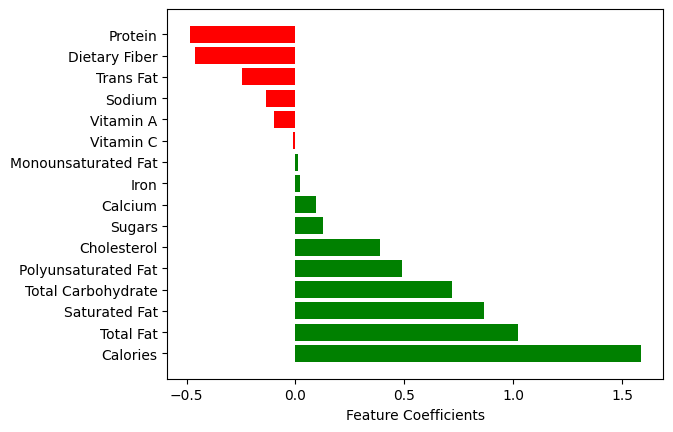

In [729]:
# coefficents for Class 1, `Less Often`
coef_dict = get_feature_coefs(clf, 1, feature_cols)
visualize_coefs(coef_dict)

#### Unhealthy nutrients such as `Saturated Fat`, `Sugars`, `Cholesterol`, `Total Fat`, other fats., have high positive coefficients.
- Food items containing unhealthy nutrients will have **higher coeficients** and will be more likely to be categorized in the 'Less Often' class.

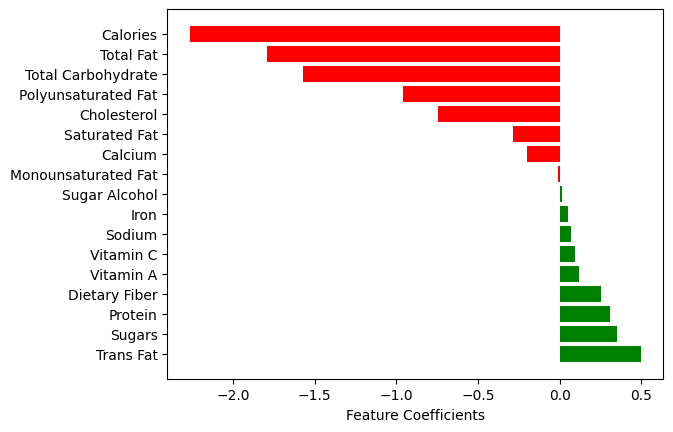

In [730]:
# coefficents for Class 2, `More Often` ==> healthiest options
coef_dict = get_feature_coefs(clf, 2, feature_cols)
visualize_coefs(coef_dict)

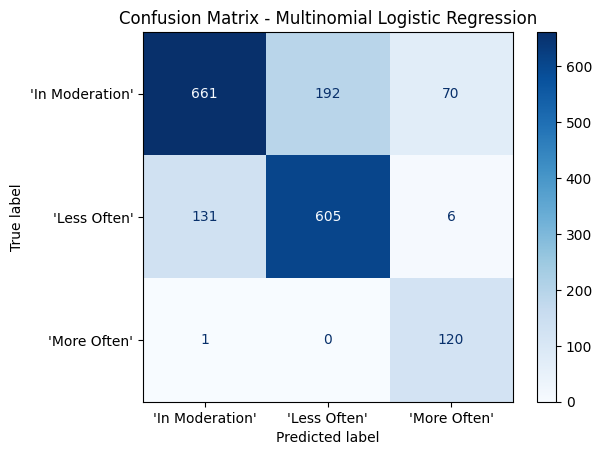

In [731]:
cm = confusion_matrix(y_test, y_pred_l2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Multinomial Logistic Regression")
plt.show()

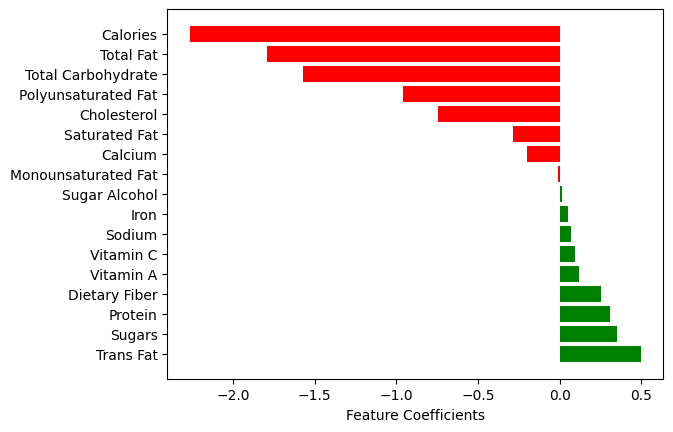

In [732]:
# coefficents for Class 1, `Less Often`
coef_dict = get_feature_coefs(clf, 2, feature_cols)
visualize_coefs(coef_dict)

In [733]:
from sklearn.linear_model import LogisticRegression

l1_model = LogisticRegression(
    penalty='l1',
    solver='saga',               
    multi_class='multinomial',   
    C=0.01,                      
    max_iter=5000,              
    random_state=42
)

l1_model.fit(X_train_scaled, y_train)

LogisticRegression(C=0.01, max_iter=5000, multi_class='multinomial',
                   penalty='l1', random_state=42, solver='saga')

In [734]:
y_pred_l1 = l1_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_l1))
print(classification_report(y_test, y_pred_l1, target_names=label_encoder.classes_))

Accuracy: 0.7760358342665173
                 precision    recall  f1-score   support

'In Moderation'       0.83      0.72      0.77       923
   'Less Often'       0.76      0.81      0.79       742
   'More Often'       0.60      0.99      0.75       121

       accuracy                           0.78      1786
      macro avg       0.73      0.84      0.77      1786
   weighted avg       0.79      0.78      0.78      1786



In [735]:
# Which features are used
# non-zero coefficients per class
nonzero_counts = np.sum(l1_model.coef_ != 0, axis=1)
print("Number of non-zero coefficients per class:", nonzero_counts)

Number of non-zero coefficients per class: [2 8 4]


In [736]:
feature_names = X_train.columns  # list of original feature names
coefs = l1_model.coef_           # shape: (n_classes, n_features)

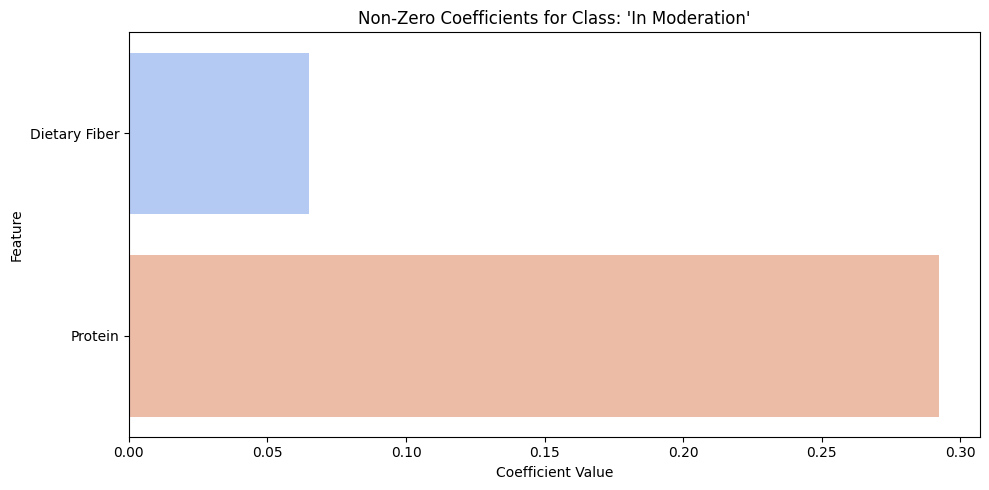

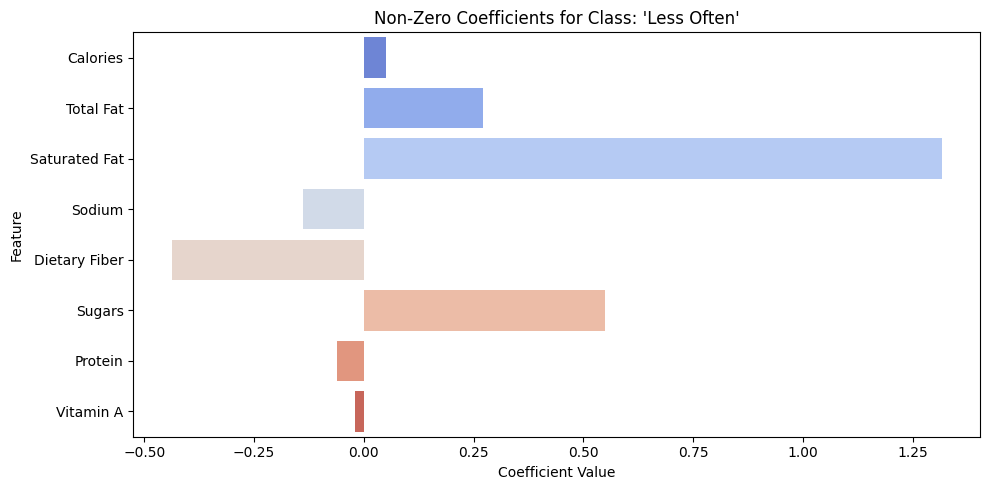

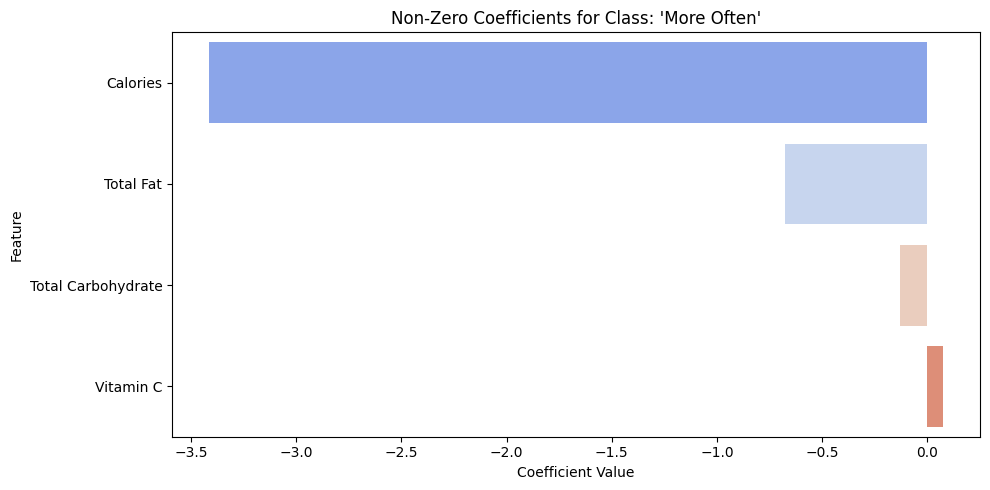

In [737]:
#class labels (e.g., 'In Moderation', 'Less Often', 'More Often')
class_labels = label_encoder.classes_

# loop over each class
for i, class_label in enumerate(class_labels):
    coef_i = coefs[i]
    nonzero_mask = coef_i != 0
    selected_features = feature_names[nonzero_mask]
    selected_coefs = coef_i[nonzero_mask]

    plt.figure(figsize=(10, 5))
    sns.barplot(x=selected_coefs, y=selected_features, palette='coolwarm')
    plt.title(f"Non-Zero Coefficients for Class: {class_label}")
    plt.xlabel("Coefficient Value")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

In [ ]:
#Conclusion
#Multinomial results were slightly better than One vs rest, Making the data balanced makes it faster for the model to learn and distinguish between the classes
#results after balancing were more consistent
#Logistic regulariation without regularization was the best model
